## 6.1. EEG/MEG Connectivity

**Learning Objectives:**
- Understand functional connectivity in EEG/MEG data
- Learn different connectivity measures and when to use them
- Compute phase-based connectivity (PLV, PLI, wPLI)
- Analyze amplitude-based connectivity (coherence, envelope correlations)
- Visualize connectivity patterns across frequency bands
- Compare connectivity between conditions and time windows

**Key Concepts:**
- **Functional Connectivity**: Statistical dependencies between brain signals
- **Phase Locking**: Consistency of phase relationships between signals
- **Coherence**: Frequency-specific correlation between signals
- **Directionality**: Identifying information flow between regions
- **Frequency Bands**: Alpha, beta, gamma connectivity patterns
- **Source-Level vs Sensor-Level**: Connectivity at different spatial scales

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import mne
from mne import io
from mne.datasets import sample
from mne_connectivity import (spectral_connectivity_epochs, 
                                spectral_connectivity_time,
                                phase_slope_index,
                                envelope_correlation)
from mne.viz import circular_layout
from mne_connectivity.viz import plot_connectivity_circle
from scipy import signal, stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.set_context("notebook", font_scale=1.2)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

### 1. Understanding Brain Connectivity

#### What is Functional Connectivity?

**Functional connectivity** measures statistical dependencies between brain signals from different regions, without requiring direct anatomical connections.

**Three main types of connectivity:**

1. **Structural Connectivity** (Anatomical):
   - Physical connections (white matter tracts)
   - Measured with: DTI, tractography
   - Static (changes slowly)

2. **Functional Connectivity**:
   - Statistical dependencies between signals
   - Measured with: EEG, MEG, fMRI
   - Dynamic (changes rapidly)

3. **Effective Connectivity** (Causal):
   - Directed influence between regions
   - Measured with: Granger causality, DCM
   - Infers information flow

**This tutorial focuses on functional connectivity in EEG/MEG.**

#### Why Study EEG/MEG Connectivity?

**Advantages of EEG/MEG:**
- **Millisecond temporal resolution** - capture fast neural dynamics
- **Frequency-specific** - analyze connectivity in different bands
- **Phase information** - reveals synchronization patterns
- **Non-invasive** - safe for repeated measurements

**Applications:**
- Understanding brain networks during cognition
- Biomarkers for neurological disorders
- Brain-computer interfaces
- Studying neural communication mechanisms

#### Connectivity Measures Overview

| Measure | Type | What It Measures | Pros | Cons |
|---------|------|------------------|------|------|
| **Coherence** | Amplitude | Frequency-specific correlation | Intuitive, well-understood | Sensitive to volume conduction |
| **PLV** | Phase | Phase locking value | Pure phase measure | Biased by volume conduction |
| **PLI** | Phase | Phase lag index | Reduces volume conduction | Less sensitive |
| **wPLI** | Phase | Weighted PLI | Good balance | More complex |
| **Envelope Correlation** | Amplitude | Correlation of amplitude envelopes | Captures slow dynamics | Requires filtering |
| **Granger Causality** | Directed | Causal influence | Directional | Assumes stationarity |

**Volume Conduction Problem:**
- EEG/MEG sensors pick up activity from multiple sources
- Creates spurious correlations between nearby sensors
- Phase-based measures with lag tolerance (PLI, wPLI) help mitigate this

### 2. Connectivity Analysis Pipeline

**Standard workflow:**

1. **Load and preprocess data**
   - Filter, epoch, reject artifacts
   
2. **Select analysis approach**:
   - **Sensor-level**: Connectivity between electrodes/sensors (faster, simpler)
   - **Source-level**: Connectivity between brain regions (more interpretable)
   
3. **Choose connectivity measure**:
   - Phase-based (PLV, PLI, wPLI) for synchronization
   - Amplitude-based (coherence) for spectral coupling
   - Directed (Granger) for information flow
   
4. **Compute connectivity**:
   - Across frequency bands
   - Over time windows
   - Between conditions
   
5. **Visualize and interpret**:
   - Connectivity matrices
   - Circle plots
   - Time-frequency representations

We'll focus on **sensor-level connectivity** with multiple measures.

In [4]:
repo_root = Path("./").resolve().parents[1]
target_dir = repo_root / "datasets" / "meg_sample"
target_dir.mkdir(parents=True, exist_ok=True)

data_path = sample.data_path(path=str(target_dir), download=True)

# Load MEG data
meg_file = data_path / "MEG" / "sample" / "sample_audvis_raw.fif"
events_fname = data_path / 'MEG' / 'sample' / 'sample_audvis_raw-eve.fif'

raw = mne.io.read_raw_fif(meg_file, preload=True)
events = mne.read_events(events_fname)

print(f"Loaded raw data: {raw}")
print(f"Number of events: {len(events)}")

Opening raw data file /Users/yibeisita/Documents/neuro-ai-playground/datasets/meg_sample/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
Loaded raw data: <Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>
Number of events: 320


In [5]:
# Basic preprocessing
raw.filter(l_freq=1.0, h_freq=40.0, verbose=False)

# Pick MEG gradiometers (good for connectivity analysis)
raw.pick_types(meg='grad', eeg=False, eog=True, stim=False)

print(f"Using {len(raw.ch_names)} gradiometer channels")
print(f"Sampling frequency: {raw.info['sfreq']} Hz")

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Using 204 gradiometer channels
Sampling frequency: 600.614990234375 Hz


In [6]:
# Event dictionary
event_id = {'auditory/left': 1, 'auditory/right': 2,
            'visual/left': 3, 'visual/right': 4}

# Create epochs
epochs = mne.Epochs(raw, events, event_id, 
                    tmin=-0.2, tmax=0.8,
                    baseline=(None, 0),
                    preload=True,
                    reject=dict(grad=4000e-13, eog=150e-6),
                    verbose=False)

print(f"\nCreated {len(epochs)} epochs")
print(f"Epoch duration: {epochs.tmax - epochs.tmin:.2f} seconds")


Created 219 epochs
Epoch duration: 1.00 seconds


In [7]:
# Select auditory epochs for analysis
epochs_auditory = epochs['auditory']
print(f"Using {len(epochs_auditory)} auditory epochs")

Using 105 auditory epochs


### 3. Selecting Sensors for Connectivity Analysis

For demonstration, we'll focus on a subset of sensors to make computation faster and visualization clearer.

**Strategy:**
- Select sensors over regions of interest
- For auditory task: temporal and parietal sensors
- Typically 10-20 sensors for clear visualization

In [20]:
# Get channel names
all_channels = epochs_auditory.ch_names
print(f"Channel names: {all_channels}")

Channel names: ['MEG 0113', 'MEG 0112', 'MEG 0122', 'MEG 0123', 'MEG 0132', 'MEG 0133', 'MEG 0143', 'MEG 0142', 'MEG 0213', 'MEG 0212', 'MEG 0222', 'MEG 0223', 'MEG 0232', 'MEG 0233', 'MEG 0243', 'MEG 0242', 'MEG 0313', 'MEG 0312', 'MEG 0322', 'MEG 0323', 'MEG 0333', 'MEG 0332', 'MEG 0343', 'MEG 0342', 'MEG 0413', 'MEG 0412', 'MEG 0422', 'MEG 0423', 'MEG 0432', 'MEG 0433', 'MEG 0443', 'MEG 0442', 'MEG 0513', 'MEG 0512', 'MEG 0523', 'MEG 0522', 'MEG 0532', 'MEG 0533', 'MEG 0542', 'MEG 0543', 'MEG 0613', 'MEG 0612', 'MEG 0622', 'MEG 0623', 'MEG 0633', 'MEG 0632', 'MEG 0642', 'MEG 0643', 'MEG 0713', 'MEG 0712', 'MEG 0723', 'MEG 0722', 'MEG 0733', 'MEG 0732', 'MEG 0743', 'MEG 0742', 'MEG 0813', 'MEG 0812', 'MEG 0822', 'MEG 0823', 'MEG 0913', 'MEG 0912', 'MEG 0923', 'MEG 0922', 'MEG 0932', 'MEG 0933', 'MEG 0942', 'MEG 0943', 'MEG 1013', 'MEG 1012', 'MEG 1023', 'MEG 1022', 'MEG 1032', 'MEG 1033', 'MEG 1043', 'MEG 1042', 'MEG 1112', 'MEG 1113', 'MEG 1123', 'MEG 1122', 'MEG 1133', 'MEG 1132', 

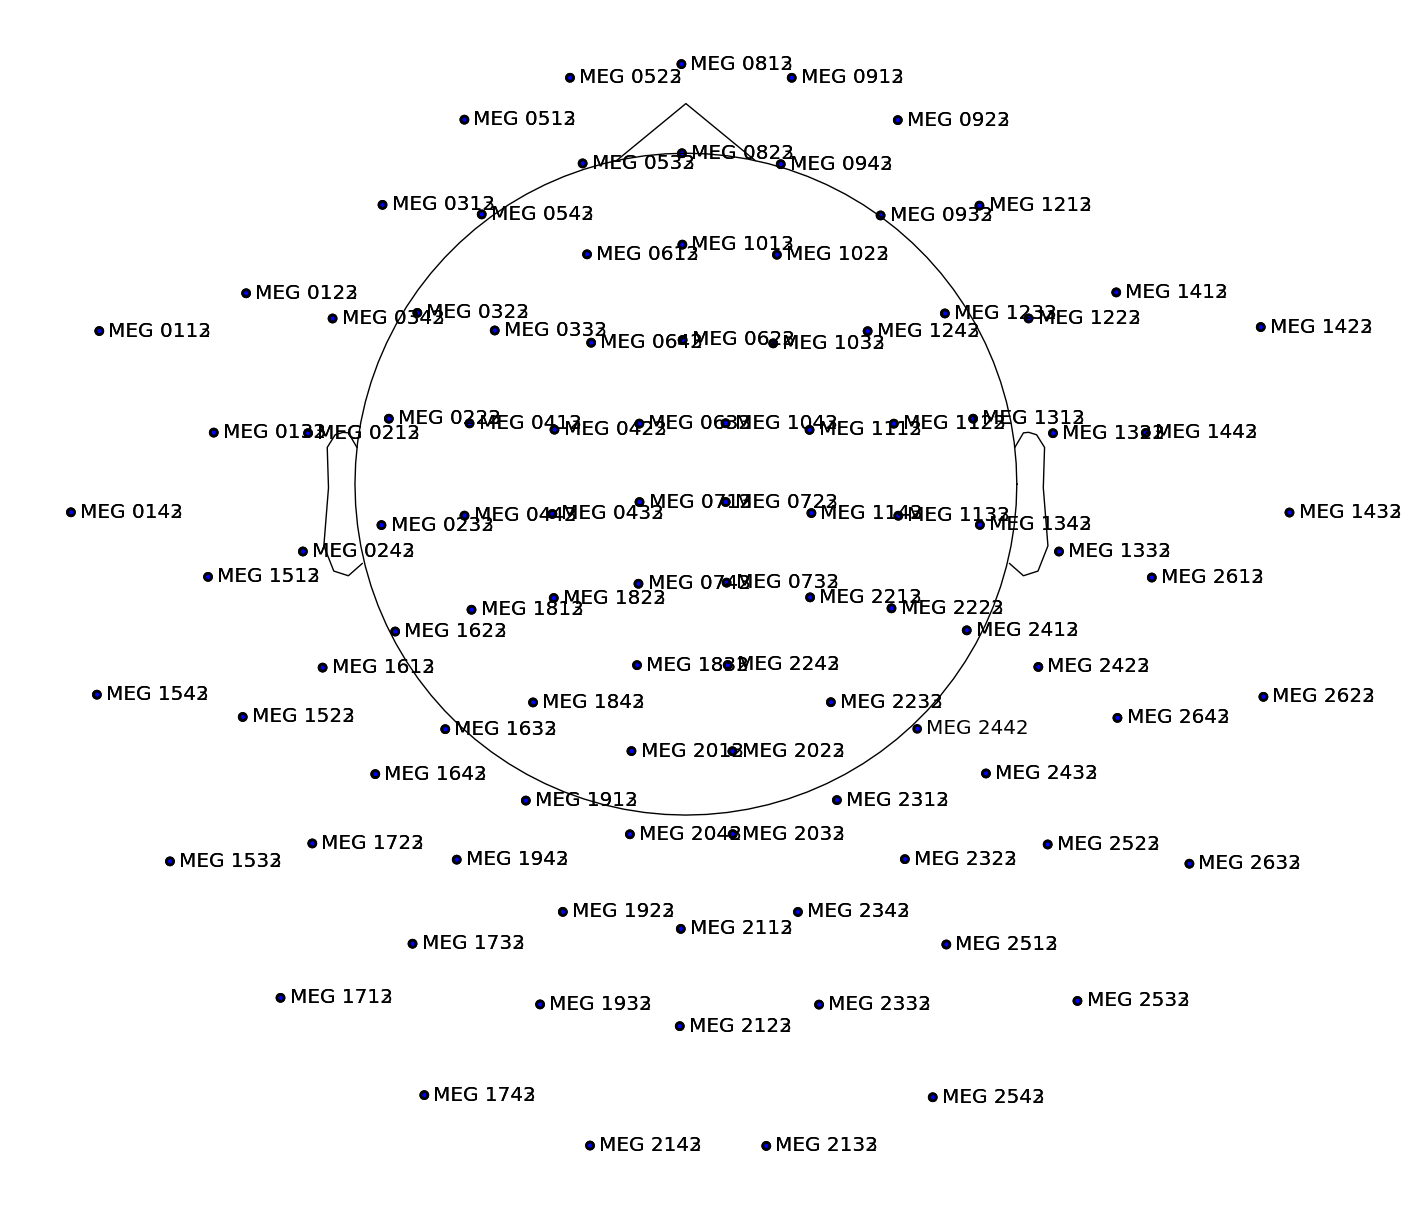

In [17]:
epochs_auditory.plot_sensors(show_names=True)
plt.show()

In [29]:
# Select channels based on naming convention
# MEG gradiometers are named by location: MEG0xxx, MEG1xxx, MEG2xxx, MEG3xxx
# We'll select representative channels from different regions

selected_channels = [
    # Left temporal (auditory cortex region)
    'MEG 0122', 'MEG 0132', 'MEG 0142',
    'MEG 0212', 'MEG 0222', 'MEG 0232',
    # Right temporal
    'MEG 1322', 'MEG 1332', 'MEG 1342',
    'MEG 1412', 'MEG 1422', 'MEG 1432',
    # Parietal
    'MEG 1622', 'MEG 1632', 'MEG 1642',
    # Frontal
    'MEG 0412', 'MEG 0422', 'MEG 0432'
]

# Verify channels exist
selected_channels = [ch for ch in selected_channels if ch in all_channels]

print(f"Selected {len(selected_channels)} channels for connectivity analysis:")
print(selected_channels)

Selected 18 channels for connectivity analysis:
['MEG 0122', 'MEG 0132', 'MEG 0142', 'MEG 0212', 'MEG 0222', 'MEG 0232', 'MEG 1322', 'MEG 1332', 'MEG 1342', 'MEG 1412', 'MEG 1422', 'MEG 1432', 'MEG 1622', 'MEG 1632', 'MEG 1642', 'MEG 0412', 'MEG 0422', 'MEG 0432']


In [31]:
# Create epochs with only selected channels
epochs_subset = epochs_auditory.copy().pick_channels(selected_channels)
print(f"\nEpochs shape: {epochs_subset.get_data().shape}")
print(f"  (n_epochs, n_channels, n_times)")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).

Epochs shape: (105, 18, 601)
  (n_epochs, n_channels, n_times)


### 4. Coherence: Frequency-Domain Connectivity

**Coherence** measures the consistency of phase and amplitude relationships at specific frequencies.

**Formula:**
$$C_{xy}(f) = \frac{|S_{xy}(f)|^2}{S_{xx}(f) \cdot S_{yy}(f)}$$

Where:
- $S_{xy}(f)$ = Cross-spectral density between signals x and y
- $S_{xx}(f)$, $S_{yy}(f)$ = Auto-spectral densities (power spectra)

**Range:** 0 (no coherence) to 1 (perfect coherence)

**Interpretation:**
- High coherence = signals oscillate together at this frequency
- Frequency-specific coupling
- Combines phase and amplitude information

**Caveat:** Sensitive to volume conduction (nearby sensors appear coherent even without true neural coupling)

In [34]:
# Compute coherence between all pairs of channels

# Define frequency bands of interest
fmin = 4.0  # Minimum frequency
fmax = 40.0  # Maximum frequency

# Compute spectral connectivity (coherence)
print("Computing coherence...")
print("(This may take a minute)")

con_coherence = spectral_connectivity_epochs(
    epochs_subset,
    method='coh',  # Coherence
    mode='multitaper',  # Use multitaper method for robust spectral estimation
    sfreq=epochs_subset.info['sfreq'],
    fmin=fmin,
    fmax=fmax,
    faverage=True,  # Average over frequency bands
    mt_adaptive=False,
    n_jobs=1,
    verbose=False
)

# Extract connectivity matrix and frequencies
coherence_matrix = con_coherence.get_data(output='dense')[:, :, 0]  # Shape: (n_channels, n_channels)

print(f"\nCoherence matrix shape: {coherence_matrix.shape}")
print(f"  ({coherence_matrix.shape[0]} channels × {coherence_matrix.shape[1]} channels)")
print(f"Frequency range: {fmin}-{fmax} Hz")

Computing coherence...
(This may take a minute)

Coherence matrix shape: (18, 18)
  (18 channels × 18 channels)
Frequency range: 4.0-40.0 Hz


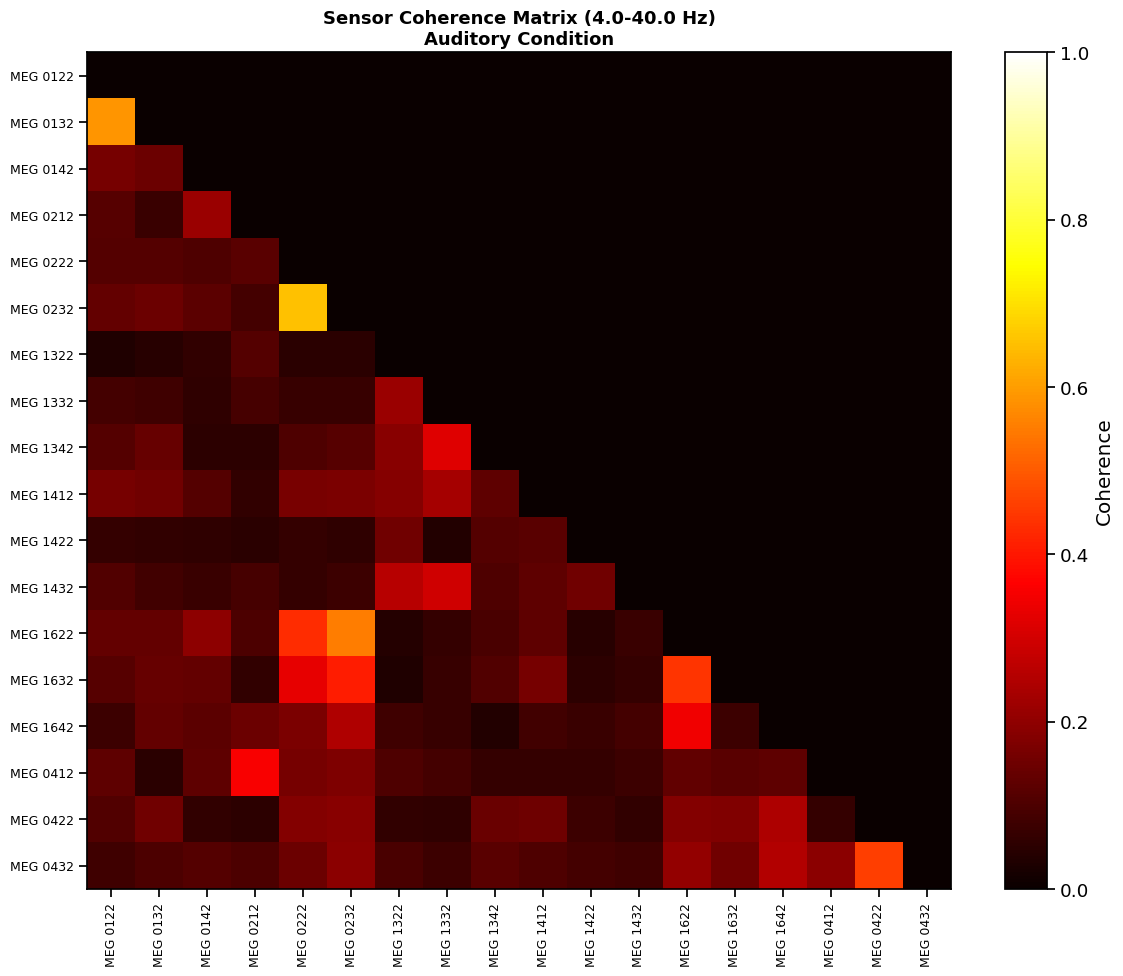


Coherence statistics:
  Mean coherence: 0.000
  Max coherence: 0.000
  Min coherence: 0.000

Top 5 strongest connections:
  MEG 0422   <-> MEG 0432  : 0.000
  MEG 0142   <-> MEG 0432  : 0.000
  MEG 0212   <-> MEG 1422  : 0.000
  MEG 0212   <-> MEG 1412  : 0.000
  MEG 0212   <-> MEG 1342  : 0.000


In [35]:
# Visualize the coherence matrix
fig, ax = plt.subplots(figsize=(12, 10))

# Plot matrix
im = ax.imshow(coherence_matrix, cmap='hot', vmin=0, vmax=1, aspect='auto', interpolation='nearest')

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Coherence')

# Channel labels
ax.set_xticks(range(len(selected_channels)))
ax.set_xticklabels(selected_channels, rotation=90, fontsize=9)
ax.set_yticks(range(len(selected_channels)))
ax.set_yticklabels(selected_channels, fontsize=9)

ax.set_title(f'Sensor Coherence Matrix ({fmin}-{fmax} Hz)\nAuditory Condition', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistics
upper_triangle = coherence_matrix[np.triu_indices_from(coherence_matrix, k=1)]
print(f"\nCoherence statistics:")
print(f"  Mean coherence: {np.mean(upper_triangle):.3f}")
print(f"  Max coherence: {np.max(upper_triangle):.3f}")
print(f"  Min coherence: {np.min(upper_triangle):.3f}")

# Find strongest connections
n_top = 5
top_indices = np.argsort(upper_triangle)[-n_top:][::-1]
triu_indices = np.triu_indices_from(coherence_matrix, k=1)
print(f"\nTop {n_top} strongest connections:")
for idx in top_indices:
    i, j = triu_indices[0][idx], triu_indices[1][idx]
    print(f"  {selected_channels[i]:10s} <-> {selected_channels[j]:10s}: {coherence_matrix[i, j]:.3f}")

### 5. Frequency-Specific Connectivity

Different frequency bands are associated with different cognitive processes:

| Band | Frequency | Associated With |
|------|-----------|-----------------|
| **Theta** | 4-8 Hz | Memory, attention |
| **Alpha** | 8-12 Hz | Inhibition, idle states |
| **Beta** | 13-30 Hz | Motor control, attention |
| **Gamma** | 30-100 Hz | Local processing, binding |

Let's compute connectivity separately for each band.

In [36]:
# Define frequency bands
freq_bands = {
    'Theta (4-8 Hz)': (4, 8),
    'Alpha (8-12 Hz)': (8, 12),
    'Beta (13-30 Hz)': (13, 30),
    'Gamma (30-40 Hz)': (30, 40)
}

# Compute coherence for each band
coherence_bands = {}

for band_name, (fmin, fmax) in freq_bands.items():
    print(f"Computing coherence for {band_name}...")
    
    con = spectral_connectivity_epochs(
        epochs_subset,
        method='coh',
        mode='multitaper',
        sfreq=epochs_subset.info['sfreq'],
        fmin=fmin,
        fmax=fmax,
        faverage=True,
        mt_adaptive=False,
        n_jobs=1,
        verbose=False
    )
    
    coherence_bands[band_name] = con.get_data(output='dense')[:, :, 0]

Computing coherence for Theta (4-8 Hz)...
Computing coherence for Alpha (8-12 Hz)...
Computing coherence for Beta (13-30 Hz)...
Computing coherence for Gamma (30-40 Hz)...


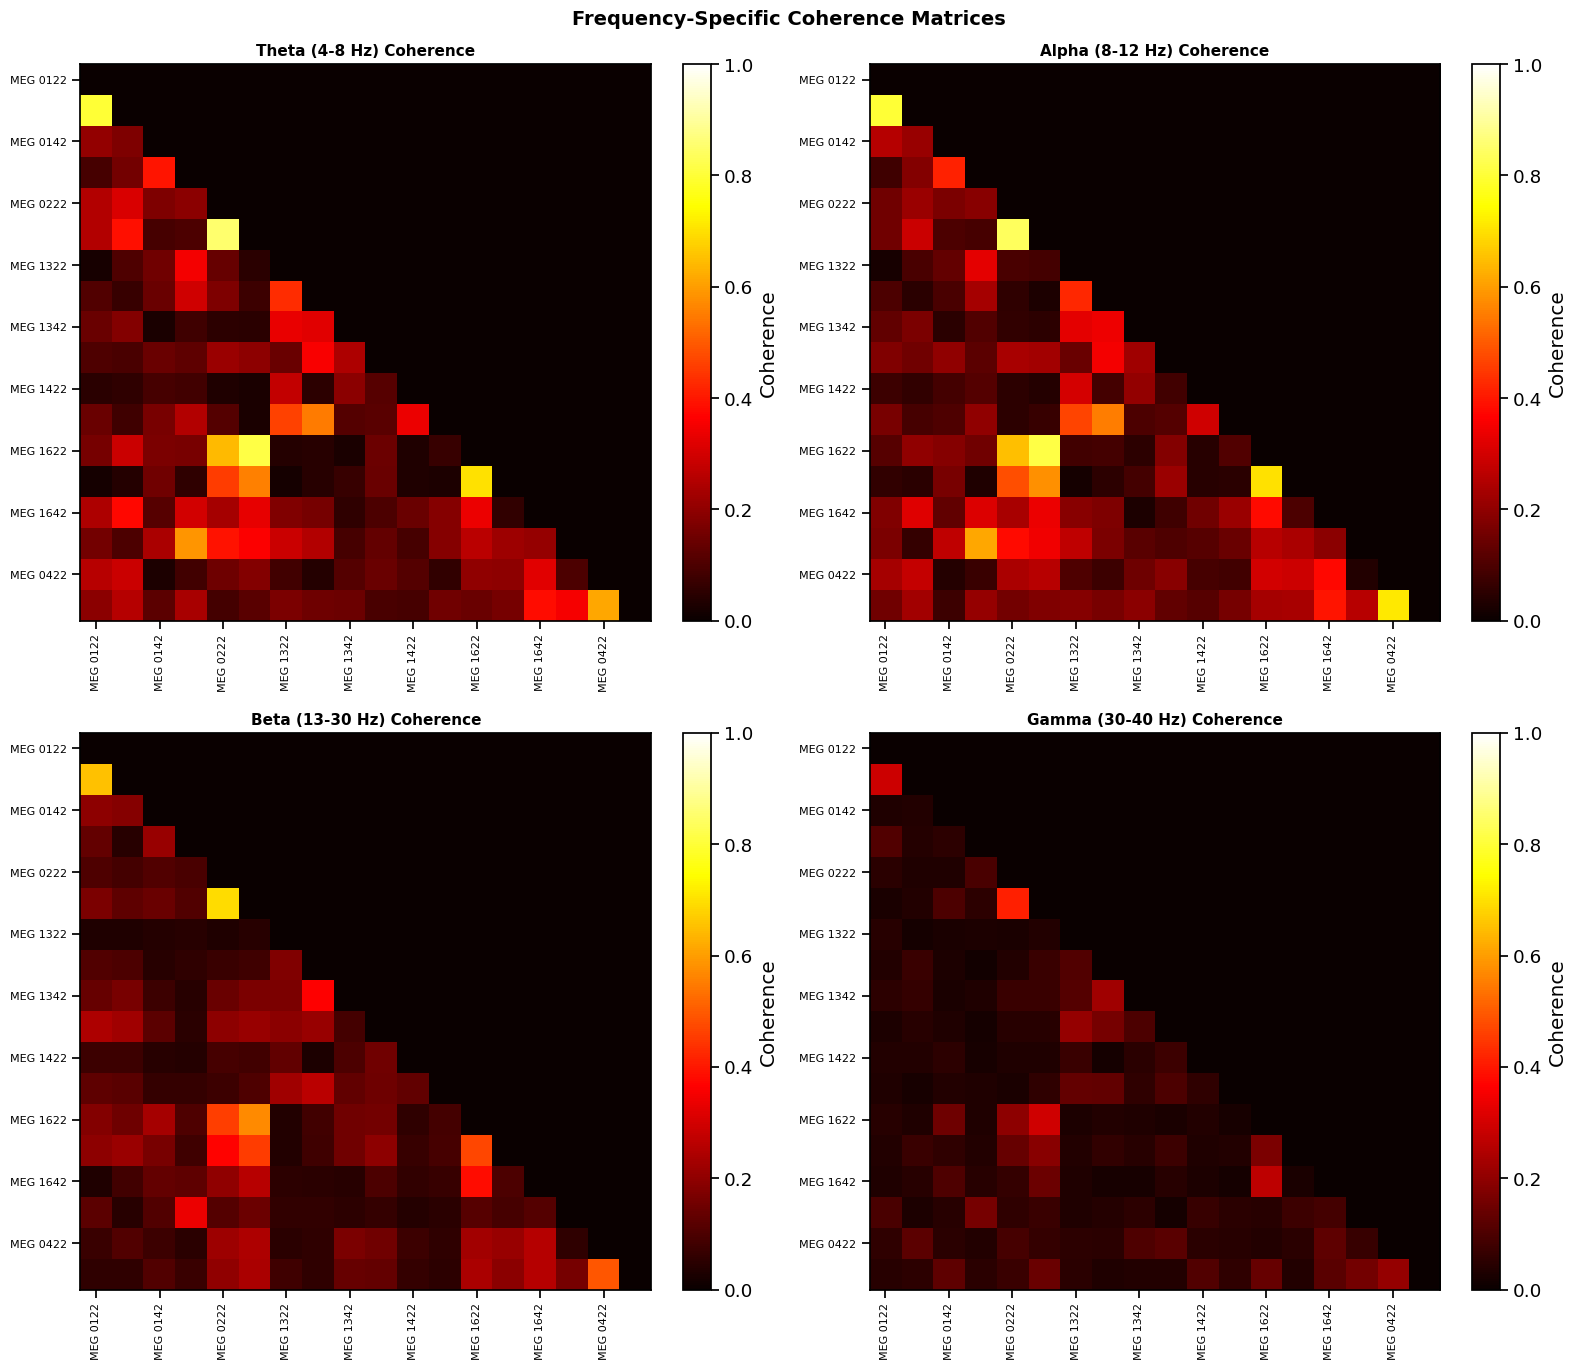

In [37]:
# Plot coherence matrices for each frequency band
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (band_name, coh_matrix) in enumerate(coherence_bands.items()):
    ax = axes[idx]
    
    # Plot matrix
    im = ax.imshow(coh_matrix, cmap='hot', vmin=0, vmax=1, aspect='auto', interpolation='nearest')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label='Coherence', fraction=0.046)
    
    # Labels - show every 2nd label to avoid crowding
    tick_positions = range(0, len(selected_channels), 2)
    tick_labels = [selected_channels[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels, fontsize=8)
    
    ax.set_title(f'{band_name} Coherence', fontsize=11, fontweight='bold')

plt.suptitle('Frequency-Specific Coherence Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# Compare average coherence across bands
print("\nAverage coherence by frequency band:")
for band_name, coh_matrix in coherence_bands.items():
    upper_triangle = coh_matrix[np.triu_indices_from(coh_matrix, k=1)]
    print(f"  {band_name:20s}: {np.mean(upper_triangle):.3f}")


Average coherence by frequency band:
  Theta (4-8 Hz)      : 0.000
  Alpha (8-12 Hz)     : 0.000
  Beta (13-30 Hz)     : 0.000
  Gamma (30-40 Hz)    : 0.000
